In [2]:
import pandas as pd
from sklearn.cluster import KMeans

In [8]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [4]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [5]:
X

array([[ -9.31559983,   9.24709374],
       [ -2.45204805,  -5.07736367],
       [ -9.82161554,   8.75809852],
       ...,
       [-10.77935662,   8.73569927],
       [ -2.36205093,  -7.466145  ],
       [ -6.04401947,   4.62024402]], shape=(1000, 2))

In [6]:
y

array([2, 0, 2, 0, 2, 0, 0, 2, 1, 2, 0, 1, 2, 0, 0, 2, 0, 2, 2, 1, 1, 1,
       0, 0, 2, 1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 2, 1, 0, 1, 0, 0, 2, 1, 0, 1, 0, 2,
       2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 2, 0, 0, 0, 1, 0, 2, 1, 1, 0,
       2, 1, 1, 0, 0, 0, 1, 2, 1, 0, 2, 1, 0, 0, 1, 1, 1, 2, 1, 2, 1, 1,
       2, 2, 2, 2, 2, 1, 0, 1, 0, 0, 2, 2, 0, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       1, 1, 1, 2, 1, 0, 0, 0, 2, 1, 2, 0, 1, 2, 2, 2, 0, 2, 2, 0, 0, 0,
       1, 2, 1, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 0, 2, 0, 1,
       1, 0, 1, 2, 0, 0, 2, 1, 0, 0, 2, 2, 1, 2, 1, 2, 2, 0, 1, 1, 2, 1,
       0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 1, 0, 1, 2, 1, 1, 0, 0, 0, 0, 2,
       1, 1, 1, 1, 1, 0, 2, 2, 1, 2, 2, 1, 1, 0, 2, 2, 1, 1, 0, 1, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 1, 0, 2, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 2,
       2, 1, 0, 0, 0, 1, 1, 0, 1, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 1, 2, 0,
       0, 1, 2, 1, 0, 1, 2, 0, 2, 0, 2, 0, 1, 0, 1,

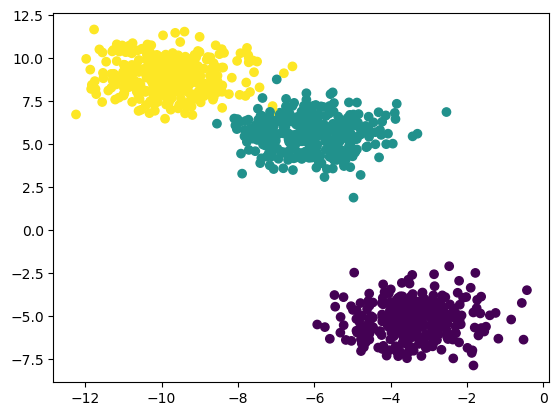

In [9]:
plt.scatter(X[:,0],X[:,1],c=y)

In [11]:
# standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [13]:
from sklearn.model_selection import train_test_split as tts

In [15]:
X_train,X_test,y_train,y_test=tts(X,y,test_size=0.33,random_state=42)

In [17]:
scaled_X_train=scaler.fit_transform(X_train)

In [18]:
scaled_X_test=scaler.transform(X_test)

In [20]:
## Elbow Method
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(scaled_X_train)
    wcss.append(kmeans.inertia_)

C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

In [21]:
wcss

[1340.0000000000002,
 327.7973935816023,
 96.5230198558399,
 76.44801010737349,
 62.21291865392615,
 47.214536286916015,
 42.536881587433825,
 38.7161554358607,
 36.60503439432492,
 31.224022284308166]

Text(0, 0.5, 'WCSS')

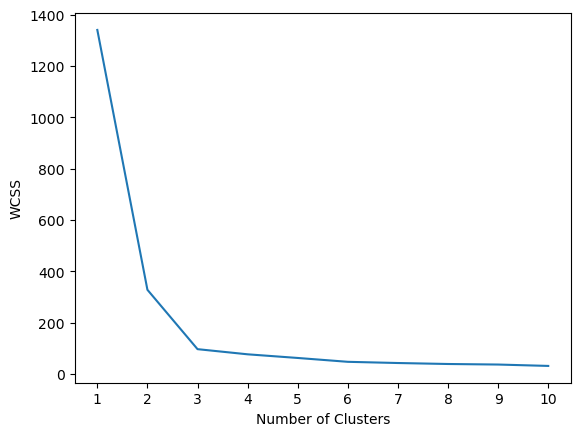

In [22]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

In [23]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [28]:
X_test_pred=kmeans.predict(scaled_X_test)

In [27]:
X_train_pred=kmeans.fit_predict(scaled_X_train)

C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


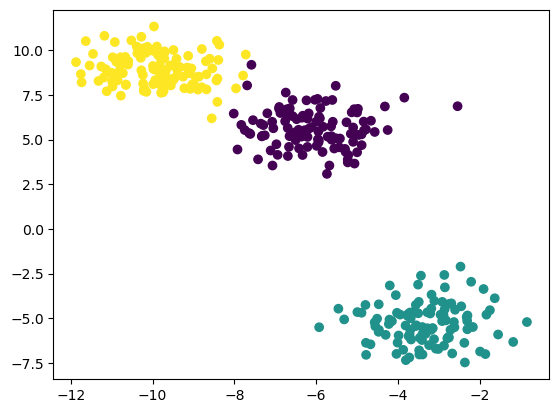

In [29]:
plt.scatter(X_test[:,0],X_test[:,1],c=X_test_pred)

In [30]:
## Validating K value

In [40]:
## Knee Locater

In [32]:
!pip install kneed

In [35]:
from kneed import KneeLocator

In [37]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [39]:
print(kl.elbow)

3


In [41]:
## silhoutee Scoring
from sklearn.metrics import silhouette_score

In [47]:
silhouette_coeff=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(scaled_X_train)
    score=silhouette_score(scaled_X_train,kmeans.labels_)
    silhouette_coeff.append(score)

C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\Abrar Khan\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a m

In [48]:
silhouette_coeff

[0.6829325984511976,
 0.7006525612126593,
 0.5973002158743836,
 0.5383306060105305,
 0.4165321546546862,
 0.3904181936809408,
 0.3763955263242393,
 0.3692875079097823,
 0.3557063736548162]

Text(0.5, 0, 'No. of clusters')

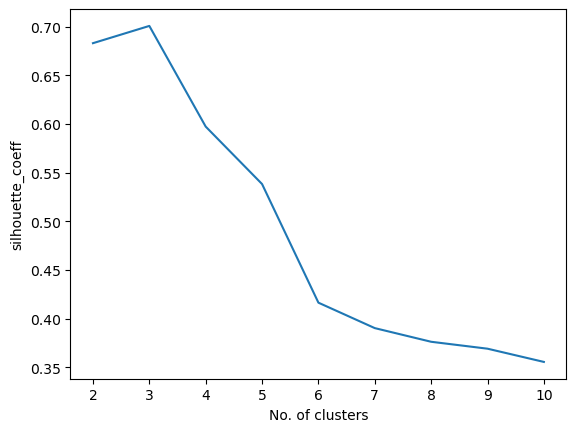

In [49]:
## plot elbow curve
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))
plt.ylabel('silhouette_coeff')
plt.xlabel('No. of clusters')